8 Queens Problem

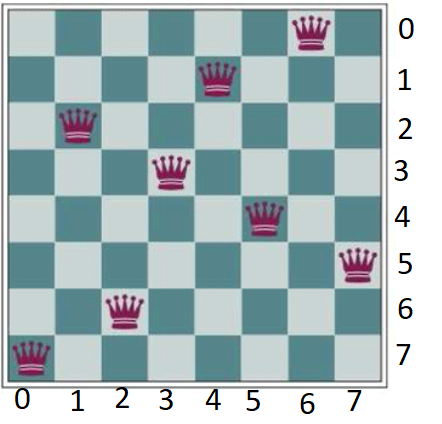

In [1]:
import random

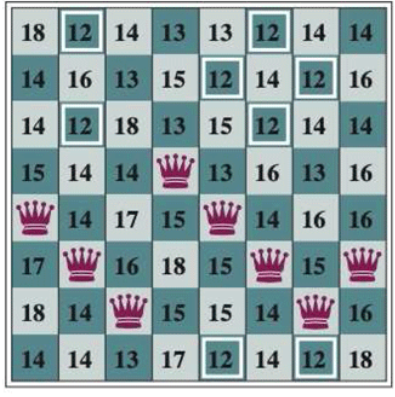
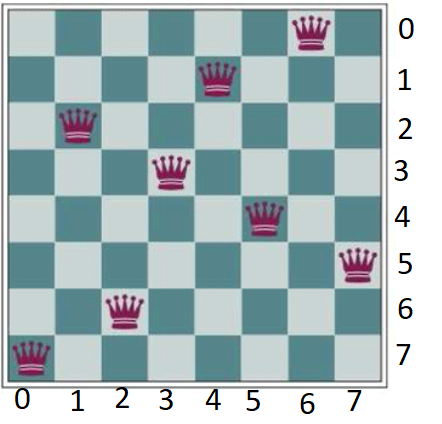

In [2]:
def get_random_board():
    # board = [ 4,5,6,3,4,5,6,5 ]
    return [ random.randint(0,7) for i in range(8) ]

def count_conflicts(board):
    conflicts = 0
    for i in range(len(board)):
        for j in range(i+1,len(board)):
            if board[i]==board[j] or abs(i-j) == abs(board[i]-board[j]):
                conflicts+= 1
    return conflicts

def display_board(board):
    for i in range(8):
        for j in range(8):
            if board[j] == i:
                print('1',end=' ')
            else:
                print("0",end=" ")
        print()
# Testing
print(count_conflicts([4,5,6,3,4,5,6,5]))
l = get_random_board()
print(l)
display_board(l)

17
[6, 6, 0, 1, 5, 0, 5, 4]
0 0 1 0 0 1 0 0 
0 0 0 1 0 0 0 0 
0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 
0 0 0 0 0 0 0 1 
0 0 0 0 1 0 1 0 
1 1 0 0 0 0 0 0 
0 0 0 0 0 0 0 0 


Solving Problem using <b>Hill-climbing Search</b>

In [3]:
def get_best_successor(current_board, current_conflicts):
    best_board = current_board
    best_conflicts = current_conflicts

    for col in range(8):
        temp = current_board.copy()
        for row in range(8):
            temp[col] = row
            x = count_conflicts(temp)
            if(best_conflicts>x):
                best_conflicts = x
                best_board = temp.copy()
    return best_board,best_conflicts

def Hill_climbing():
    # Init
    print("Initial State:")
    board = get_random_board()
    conflicts = count_conflicts(board)
    print(f"Number of conflicts = {conflicts}")
    display_board(board)
    print("-------------------------------------------------------\n")
    
    while conflicts > 0:
        best_successor,best_successor_conflicts = get_best_successor(board, conflicts)
        if best_successor_conflicts>=conflicts:
            break
        board = best_successor
        conflicts = best_successor_conflicts

    print(f"Number of conflicts = {conflicts}")
    display_board(board)

Execution

In [6]:
Hill_climbing()

Initial State:
Number of conflicts = 6
1 0 0 0 1 0 0 0 
0 0 0 0 0 1 0 0 
0 0 0 0 0 0 0 1 
0 1 1 0 0 0 0 0 
0 0 0 0 0 0 0 0 
0 0 0 1 0 0 0 0 
0 0 0 0 0 0 0 0 
0 0 0 0 0 0 1 0 
-------------------------------------------------------

Number of conflicts = 0
1 0 0 0 0 0 0 0 
0 0 0 0 0 1 0 0 
0 0 0 0 0 0 0 1 
0 0 1 0 0 0 0 0 
0 0 0 0 0 0 1 0 
0 0 0 1 0 0 0 0 
0 1 0 0 0 0 0 0 
0 0 0 0 1 0 0 0 


Solving 8 Queens using <b>Random Restart Hill Climbing</b> 

In [7]:
def Random_restart_hill_climbing():
    while True:
        current_board = get_random_board()
        current_conflicts = count_conflicts(current_board)
        while True:
            best_successor,best_successor_conflicts = get_best_successor(current_board,current_conflicts)
            if best_successor_conflicts>=current_conflicts:
                break
            current_board = best_successor
            current_conflicts = best_successor_conflicts

        if current_conflicts==0:
            print(f"Number of conflicts = {count_conflicts(current_board)}")
            display_board(current_board)
            break

Execution

In [13]:
Random_restart_hill_climbing()

Number of conflicts = 0
0 0 1 0 0 0 0 0 
0 0 0 0 0 1 0 0 
0 1 0 0 0 0 0 0 
0 0 0 0 0 0 1 0 
1 0 0 0 0 0 0 0 
0 0 0 1 0 0 0 0 
0 0 0 0 0 0 0 1 
0 0 0 0 1 0 0 0 
